# Description
______

This script analyzes HYPE future climate and historical simulations as follows:
- The official Ouranos ESPO-G6-R2 v1.0.0 ensemble which includes 15 models with SSP2-4.5 and SSP3-7.0 for a total of 30 ensemble members is used.
- For each of the 30 members, the mean annual flow volume was calculated (sum of flow for each year then calculate the mean across each year) from 2015 to 2100.
- The models that are closest to the median, 75th percentile and 25th percentile of the mean annual flow volume at SMRIB and MREIB were selected from the 30 members (SSP2-4.5 and SSP3-7.0).
- The average annual hydrographs at both gauges are plotted

### Import Libraries

In [1]:
import xarray as xr
import os
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.parser import ParserError
import cycler
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
import matplotlib.gridspec as gridspec

### Inputs

In [2]:
# Results directory
results_directory = '../../results/v10_3_results_CORRECT/'

bc_dir='../../results/bias_correction/full_bias_corr/' 

no_drizz_dir= '../../results/bias_correction/no_drizz_full_bias_corr/'

# Start and end years for the future climate period
start_year= 2015
end_year= 2099

# Start and end years for historical climate period
hist_start= 1981
hist_end= 2015

# HYPE output variable
variable= 'cout' 

# Path to HYPE output files
mreib_historical_path= '../../../SMM_Models/hype/model/v10_model/final_model/old_hds_v1/results/0058308.txt'
smrib_historical_path= '../../../SMM_Models/hype/model/v10_model/final_model/old_hds_v1/results/0058208.txt'

# Output directory for plots
output_directory= './bc_plots/'

### Define Functions

In [3]:
def process_average_annual_ensemble(results_directory: str, 
                     subbasin_id: str, 
                     scenario: str, 
                     start_year: int, 
                     end_year: int, 
                     variable: str) -> xr.DataArray:
    """
    Processes ensemble data for a specified subbasin, scenario, and variable, 
    filtering by start and end year, and calculates average annual runoff.

    Parameters:
        results_directory (str): Directory containing the ensemble files.
        subbasin_id (str): Subbasin ID to filter the files.
        scenario (str): Scenario identifier to filter the files.
        start_year (int): Start year for filtering data.
        end_year (int): End year for filtering data.
        variable (str): Variable name to select from the dataset.

    Returns:
        xr.DataArray: Processed average annual runoff shifted to start on October 1st.
    """
    # List of member names to exclude
    exclude_members = [
        "CanESM5", "CNRM-CM6-1", "EC-Earth3", "IPSL-CM6A-LR", "UKESM1-0-LL",
        "NorESM2-MM", "EC-Earth3-CC", "NESM3", "EC-Earth3-Veg", "INM-CM4-8", "TaiESM1"
    ]
    
    # Check for files of required subbasin and scenario
    file_list = [os.path.join(results_directory, filename) 
                 for filename in os.listdir(results_directory) 
                 if (subbasin_id in filename) and (scenario in filename)]

   # print(file_list)            
    
    # Create an empty list to store xarray DataArrays
    data_arrays: List[xr.DataArray] = []

    # Loop through each file
    for file_path in file_list:
        # Skip files with excluded member names
        if any(member in file_path for member in exclude_members):
            continue
        
        # Read the file into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\t', index_col=0, low_memory=False)

        # Drop the first row
        df = df.iloc[1:]

        # Convert the DataFrame to an xarray DataArray
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'), coords={'DATE': df.index, 'variable': df.columns})

        # Append the DataArray to the list
        data_arrays.append(data_array)

    # Concatenate the list of DataArrays along a new dimension 'member'
    ds = xr.concat(data_arrays, dim='member')

    # Convert 'DATE' coordinate to datetime, specifying the format and handling errors
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')

    # Convert 'member' coordinate to float
    ds = ds.astype(float)

    # Select the specified variable from the dataset
    var_data = ds.sel(variable=variable)

    # Sort the dataset along the 'DATE' coordinate
    var_data = var_data.sortby('DATE')

    # Filter the sorted dataset to include only data between the specified years
    var_data = var_data.sel(DATE=(var_data['DATE'].dt.year >= start_year) & (var_data['DATE'].dt.year <= end_year))

    # Calculate the mean of these daily means for each member to get the average annual runoff
    average_annual_runoff = var_data.groupby('DATE.dayofyear').mean(dim='DATE')

    # Drop leap day (dayofyear = 366)
    average_annual_runoff = average_annual_runoff.sel(dayofyear=~(average_annual_runoff['dayofyear'] == 366))
    
    # Shift data to start on October 1st
    dayofyear_shifted = ((average_annual_runoff['dayofyear'] - 274) % 365) + 1

    # Update the 'dayofyear' coordinate with the shifted values
    average_annual_runoff['dayofyear'] = dayofyear_shifted

    # Sort the data_array along the 'dayofyear' coordinate
    average_annual_runoff_shifted = average_annual_runoff.sortby('dayofyear')
    
    return average_annual_runoff_shifted

In [4]:
def process_historical(filepath: str, variable: str, start_date: str = '1981-01-01', end_date: str = '2015-12-31') -> pd.Series:
    """
    Processes historical data from HYPE output files into an average annual timeseries

    Parameters:
        filepath (str): Path to the HYPE output file.
        variable (str): The variable name in the file to process.
        start_date (str): The start date for the data filter (default is '1981-01-01').
        end_date (str): The end date for the data filter (default is '2015-12-31').

    Returns:
        pd.Series: A pandas Series with the historical average annual timeseries
    """
    
    # Read the tab-separated text file into a DataFrame
    sim: pd.DataFrame = pd.read_csv(filepath, delimiter='\t', index_col=0, low_memory=False)
    
    # Drop the first row
    sim = sim.iloc[1:]
    
    # Drop all columns except for 'variable'
    sim = sim[[variable]]
    
    # Convert index to datetime
    sim.index = pd.to_datetime(sim.index)
    
    # Trim the DataFrame between dates
    sim = sim.loc[start_date:end_date]
    
    # Get the length of the DataFrame before dropping NaN values
    original_length: int = len(sim)
    
    # Convert the 'variable' column to numeric
    sim[variable] = pd.to_numeric(sim[variable], errors='coerce')

    # Replace -9999 values with NaN
    sim[variable] = sim[variable].replace(-9999, pd.NA)
    
    # Drop NaN values if any
   # sim = sim.dropna()
    
    # Get the length of the DataFrame after dropping NaN values
    new_length: int = len(sim)
    
    # Check if any NaN values were replaced
    if new_length < original_length:
        print("NaN values were replaced during conversion.")

    # Resample the data to calculate the mean for each day of the year across all years
    sim_resampled: pd.Series = sim.groupby(sim.index.dayofyear)[variable].mean()

    # Drop leap day (dayofyear = 366) if it exists to be consistent with future climate members
    sim_resampled = sim_resampled[sim_resampled.index != 366]

    # Shift dayofyear to start on October 1st and wrap around
    dayofyear_shifted = ((sim_resampled.index - 274) % 365) + 1

    # Update the index of the Series with the shifted dayofyear values
    sim_resampled.index = dayofyear_shifted

    # Sort the Series by index to ensure the correct order
    sim_shifted = sim_resampled.sort_index()
    
    return sim_shifted

In [5]:
def TtCoM(data):
    """Compute the Time to Center of Mass (TtCoM)"""
    days = np.arange(1, 366)  # Days 1 to 365
    total_flow = np.sum(data)
    
    if total_flow > 0:
        return np.sum(days * data) / total_flow
    else:
        return np.nan

def TtP(data):
    """Compute the Time to Peak (TtP)"""
    if isinstance(data, xr.DataArray):  # Check if data is an xarray DataArray
        return int(data.argmax().item()) + 1  # Convert to integer
    else:
        return np.argmax(data) + 1  # Use NumPy's argmax for regular arrays
        
def SpringPulseOnset(data):
    """Compute the onset of the spring pulse"""
    mean_flow = np.mean(data)
    cumulative_sum = np.cumsum(data - mean_flow)
    
    if isinstance(data, xr.DataArray):  
        onset_day = int(cumulative_sum.argmin().item()) + 1  # Ensure we get a raw integer
    else:
        onset_day = np.argmin(cumulative_sum) + 1
    
    return onset_day

In [6]:
def compute_hydrologic_metrics(data, mean_dim=None, historical=None):
    """
    Compute Time to Center of Mass (TtCoM), Time to Peak (TtP), 
    Spring Pulse Onset, and Total Flow Volume for a given DataArray. 
    If historical values are provided, return both the computed values 
    and the difference between the current ensemble and the historical values 
    (future - historical).

    Parameters:
        data (xr.DataArray): Input hydrologic data.
        mean_dim (str, optional): Dimension along which to compute the mean 
                                  before applying metrics.
        historical (list, optional): A list of historical values for comparison 
                                     [TtCoM, TtP, Spring Pulse Onset, Total Volume].

    Returns:
        tuple: 
            - result (list): [TtCoM, TtP, Spring Pulse Onset, Peak Flow, Total Volume] as numeric values.
            - difference (list or None): [Computed - Historical] for each metric if historical is provided, otherwise None.
                                         A negative value indicates the event is occurring earlier.
    """
    if mean_dim:
        data_mean = data.mean(dim=mean_dim)
    else:
        data_mean = data

    # Compute metrics
    ttcom = float(TtCoM(data_mean))  # Time to Center of Mass
    ttp = int(TtP(data_mean))  # Time to Peak
    spring_pulse_onset = int(SpringPulseOnset(data_mean))  # Spring Pulse Onset
    peak_flow = float(data_mean.max().item())  # Peak Flow as maximum value
    total_volume = float(data_mean.sum().item()) * 86400  # Total Volume (converted to volume)

    # Result list
    result = [ttcom, ttp, spring_pulse_onset, peak_flow, total_volume]

    if historical:
        # Compute the difference for each metric
        difference = [
            r - h if i != 4 else ((r - h) / h) * 100  # For volume, compute percentage difference
            for i, (r, h) in enumerate(zip(result, historical))
        ]
        return result, difference

    return result, None

In [7]:
# Merge ensembles by taking combined quantiles
def combine_ensembles(*arrays):
    combined = xr.concat(arrays, dim='member')
    return {
        'q025': combined.quantile(0.025, dim='member'),
        'q975': combined.quantile(0.975, dim='member'),
        'median': combined.median(dim='member')
    }

In [8]:
# Create a dictionary to map variables to corresponding names and units
variable_dict = {
    'cout': {'name': 'Streamflow', 'unit': 'cms'},
    'upsnow': {'name': 'Mean Upstream SWE', 'unit': 'mm'},
    'upsoim': {'name': 'Mean Upstream Soil Moisture', 'unit': 'mm'},
    'upcprc': {'name': 'Mean Upstream Precipitation', 'unit': 'mm/day'},
    'upctmp': {'name': 'Mean Upstream Temperature', 'unit': 'C'}
}

# Assuming `variable` is one of the keys in the dictionary
variable_name = variable_dict[variable]['name']
variable_unit = variable_dict[variable]['unit']

In [9]:
def plot_bias_corrected_vs_historical(
    location,
    variable,
    variable_name,
    variable_unit,
    bc_type,
    mreib_historical,
    mreib_hist_ssp245,
    mreib_hist_ssp370,
    bc_mreib_hist_ssp245,
    bc_mreib_hist_ssp370,
    output_directory,
    combine_ensembles,
    compute_hydrologic_metrics,
    mreib_obs_historical=None
):
    """
    Plot bias-corrected historical vs. historical hydrologic time series with shaded percentiles.

    Parameters:
        variable (str): Variable identifier, e.g., 'cout'.
        variable_name (str): Readable variable name, e.g., 'Streamflow'.
        variable_unit (str): Unit of variable, e.g., 'm³/s'.
        mreib_historical (pd.Series or pd.DataFrame): Historical forcing data.
        mreib_hist_ssp245, mreib_hist_ssp370: Historical ensemble data for SSPs.
        bc_mreib_hist_ssp245, bc_mreib_hist_ssp370: Bias-corrected ensemble data.
        output_directory (str): Path to save the output plot.
        combine_ensembles (function): Function to combine ensemble datasets.
        compute_hydrologic_metrics (function): Function to compute flow timing/volume metrics.
        mreib_obs_historical (pd.Series, optional): Observed naturalized historical data.

    Returns:
        None
    """
    plt.figure(figsize=(16, 8))

    # Define colors
    bc_color = 'royalblue'
    historical_color = 'seagreen'
    historical_forcing_color = 'red'
    historical_obs_color = 'black'

    # Plot historical forcing
    mreib_historical.plot(label='RDRSv2.1. Historical (1981–2015)', color=historical_forcing_color)

    # Optionally plot observed historical
    if variable == 'cout' and mreib_obs_historical is not None:
        mreib_obs_historical.plot(label='Naturalized Historical (1981–2015)', color=historical_obs_color, alpha=0.7)

    # Combine ensembles
    bc_combined = combine_ensembles(bc_mreib_hist_ssp245, bc_mreib_hist_ssp370)
    hist_combined = combine_ensembles(mreib_hist_ssp245, mreib_hist_ssp370)

    # Fill percentile range
    plt.fill_between(bc_mreib_hist_ssp245['dayofyear'], bc_combined['q025'], bc_combined['q975'],
                     color=bc_color, alpha=0.2)
    plt.fill_between(mreib_hist_ssp245['dayofyear'], hist_combined['q025'], hist_combined['q975'],
                     color=historical_color, alpha=0.2)

    # Plot medians
    bc_combined['median'].plot(color=bc_color, linestyle='-', label='Bias-Corrected Historical (2015–2100)')
    hist_combined['median'].plot(color=historical_color, linestyle='-', label='Historical (1981–2015)')

    # Compute metrics
    historical_stats, _ = compute_hydrologic_metrics(mreib_historical)
    bc_stats, bc_diff = compute_hydrologic_metrics(bc_combined['median'], historical=historical_stats)
    hist_stats, hist_diff = compute_hydrologic_metrics(hist_combined['median'], historical=historical_stats)

    # Legend
    legend_handles = [
        Patch(facecolor=historical_color, alpha=0.2, label='Ouranos Historical (1981–2015) 0.025–0.975 Percentile'),
        Patch(facecolor=bc_color, alpha=0.2, label=f'{bc_type} Ouranos Historical (1981-2015) 0.025–0.975 Percentile'),
        Line2D([0], [0], color=historical_forcing_color, lw=2, label='RDRSv2.1. Historical (1981–2015)'),
        Line2D([0], [0], color=historical_color, lw=2, label='Ouranos Historical Median'),
        Line2D([0], [0], color=bc_color, lw=2, label=f'{bc_type} Ouranos Historical Median')
    ]
    if variable == 'cout' and mreib_obs_historical is not None:
        legend_handles.append(Line2D([0], [0], color=historical_obs_color, lw=2, label='Naturalized Historical (1981–2015)'))

    plt.legend(handles=legend_handles)

    # Labels and title
    plt.xlabel('Day of Year (Starting Oct 1st)')
    plt.ylabel(f'Average Daily {variable_name} ({variable_unit})')
    plt.title(f'{location} Ouranos {bc_type} Average Daily {variable_name}')

    # Annotations
    x_pos = 1.02
    y_offset = 0.96

    for stats, diff, label, color in [
        (historical_stats, (0, 0, 0, 0, 0), 'RDRSv2.1. Historical (1981–2015):', historical_forcing_color),
        (hist_stats, hist_diff, 'Ouranos Hist (1981–2015):', historical_color),
        (bc_stats, bc_diff, f'{bc_type} Ouranos Hist (1981-2015):', bc_color)
    ]:
        ttcom, ttp, spring_pulse_onset, peak_flow, total_volume = stats
        d_ttcom, d_ttp, d_spring_pulse_onset, d_peak_flow, d_total_volume = diff

        annotation = (
            f"{label}\n"
            f"TtCoM: {ttcom:.1f} days (Δ: {d_ttcom:.1f})\n"
            f"TtP: {ttp:.1f} days (Δ: {d_ttp:.1f})\n"
            f"SpringOnset: {spring_pulse_onset:.1f} days (Δ: {d_spring_pulse_onset:.1f})\n"
            f"Peak Flow: {peak_flow:.2e} m³/s (Δ: {d_peak_flow:.2f} %)\n"
            f"Volume: {total_volume:.2e} m³ (Δ: {d_total_volume:.2f} %)"
        )

        plt.text(
            x_pos, y_offset, annotation, transform=plt.gca().transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='left',
            bbox=dict(facecolor=color, alpha=0.2, boxstyle='round,pad=1')
        )
        y_offset -= 0.22

    # Save and show
    file_path_allssp = os.path.join(output_directory, f'{location}_{bc_type}_hist_{variable}.png')
    plt.savefig(file_path_allssp, bbox_inches='tight')
    plt.show()


### Find Members

#### HYPE Ouranos

In [10]:
# Create averate annual data for MREIB ssp245
mreib_ssp245= process_average_annual_ensemble(results_directory, '58308', 'ssp245', start_year, end_year, variable)

# Create average annual pseudo historical for MREIB ssp245
mreib_hist_ssp245= process_average_annual_ensemble(results_directory, '58308', 'ssp245', hist_start, hist_end, variable)

In [11]:
# Create averate annual data for MREIB ssp370
mreib_ssp370 = process_average_annual_ensemble(results_directory, '58308', 'ssp370', start_year, end_year, variable)

# Create average annual pseudo historical for MREIB ssp370
mreib_hist_ssp370 = process_average_annual_ensemble(results_directory, '58308', 'ssp370', hist_start, hist_end,  variable)

In [12]:
# Create averate annual data for SMRIB ssp245
smrib_ssp245 = process_average_annual_ensemble(results_directory, '58208', 'ssp245', start_year, end_year, variable)

# Create average annual pseudo historical for SMRIB ssp245
smrib_hist_ssp245 = process_average_annual_ensemble(results_directory, '58208', 'ssp245', hist_start, hist_end, variable)

In [13]:
# Create averate annual data for SMRIB ssp370
smrib_ssp370 = process_average_annual_ensemble(results_directory, '58208', 'ssp370', start_year, end_year, variable)

# Create average annual pseudo historical for SMRIB ssp370
smrib_hist_ssp370 = process_average_annual_ensemble(results_directory, '58208', 'ssp370', hist_start, hist_end, variable)

#### Ournaos Bias Corr

In [14]:
# Create averate annual data for MREIB ssp245
bc_mreib_ssp245= process_average_annual_ensemble(bc_dir, '58308', 'ssp245', start_year, end_year, variable)

# Create average annual pseudo historical for MREIB ssp245
bc_mreib_hist_ssp245= process_average_annual_ensemble(bc_dir, '58308', 'ssp245', hist_start, hist_end, variable)

In [15]:
# Create averate annual data for MREIB ssp370
bc_mreib_ssp370 = process_average_annual_ensemble(bc_dir, '58308', 'ssp370', start_year, end_year, variable)

# Create average annual pseudo historical for MREIB ssp370
bc_mreib_hist_ssp370 = process_average_annual_ensemble(bc_dir, '58308', 'ssp370', hist_start, hist_end,  variable)

In [16]:
# Create averate annual data for SMRIB ssp245
bc_smrib_ssp245 = process_average_annual_ensemble(bc_dir, '58208', 'ssp245', start_year, end_year, variable)

# Create average annual pseudo historical for SMRIB ssp245
bc_smrib_hist_ssp245 = process_average_annual_ensemble(bc_dir, '58208', 'ssp245', hist_start, hist_end, variable)

In [17]:
# Create averate annual data for SMRIB ssp370
bc_smrib_ssp370 = process_average_annual_ensemble(bc_dir, '58208', 'ssp370', start_year, end_year, variable)

# Create average annual pseudo historical for SMRIB ssp370
bc_smrib_hist_ssp370 = process_average_annual_ensemble(bc_dir, '58208', 'ssp370', hist_start, hist_end, variable)

#### No Drizzle Ournaos Bias Corr

In [18]:
# Create averate annual data for MREIB ssp245
no_drizz_bc_mreib_ssp245= process_average_annual_ensemble(no_drizz_dir, '58308', 'ssp245', start_year, end_year, variable)

# Create average annual pseudo historical for MREIB ssp245
no_drizz_bc_mreib_hist_ssp245= process_average_annual_ensemble(no_drizz_dir, '58308', 'ssp245', hist_start, hist_end, variable)

In [19]:
# Create averate annual data for MREIB ssp370
no_drizz_bc_mreib_ssp370 = process_average_annual_ensemble(no_drizz_dir, '58308', 'ssp370', start_year, end_year, variable)

# Create average annual pseudo historical for MREIB ssp370
no_drizz_bc_mreib_hist_ssp370 = process_average_annual_ensemble(no_drizz_dir, '58308', 'ssp370', hist_start, hist_end,  variable)

In [20]:
# Create averate annual data for SMRIB ssp245
no_drizz_bc_smrib_ssp245 = process_average_annual_ensemble(no_drizz_dir, '58208', 'ssp245', start_year, end_year, variable)

# Create average annual pseudo historical for SMRIB ssp245
no_drizz_bc_smrib_hist_ssp245 = process_average_annual_ensemble(no_drizz_dir, '58208', 'ssp245', hist_start, hist_end, variable)

In [21]:
# Create averate annual data for SMRIB ssp370
no_drizz_bc_smrib_ssp370 = process_average_annual_ensemble(no_drizz_dir, '58208', 'ssp370', start_year, end_year, variable)

# Create average annual pseudo historical for SMRIB ssp370
no_drizz_bc_smrib_hist_ssp370 = process_average_annual_ensemble(no_drizz_dir, '58208', 'ssp370', hist_start, hist_end, variable)

#### HYPE RDRS

In [22]:
# Extract historical data for SMRIB and MREIB
mreib_historical= process_historical(mreib_historical_path, variable, start_date="1981-01-01", end_date="2015-12-31")
smrib_historical= process_historical(smrib_historical_path, variable, start_date="1981-01-01", end_date="2015-12-31")

# Extract observed data for SMRIB and MREIB
mreib_obs_historical= process_historical(mreib_historical_path, 'rout', start_date="1981-01-01", end_date="2015-12-31")
smrib_obs_historical= process_historical(smrib_historical_path, 'rout', start_date="1981-01-01", end_date="2015-12-31")

In [23]:
# # MREIB average annual plot
# average_annual_plot(mreib_ssp245, mreib_ssp370, mreib_historical, 'MREIB', 'ssp245', 'ssp370', 
#                     'RDRSv2.1 Historical', start_year, end_year, 'Streamflow (cms)', output_directory)

In [24]:
# # SMRIB average annual plot
# average_annual_plot(smrib_ssp245, smrib_ssp370, smrib_historical, 'SMRIB', 'ssp245', 'ssp370', 
#                     'RDRSv2.1 Historical', start_year, end_year, 'Streamflow (cms)', output_directory)

# Plots

### BC Pseudo Hist Comparison

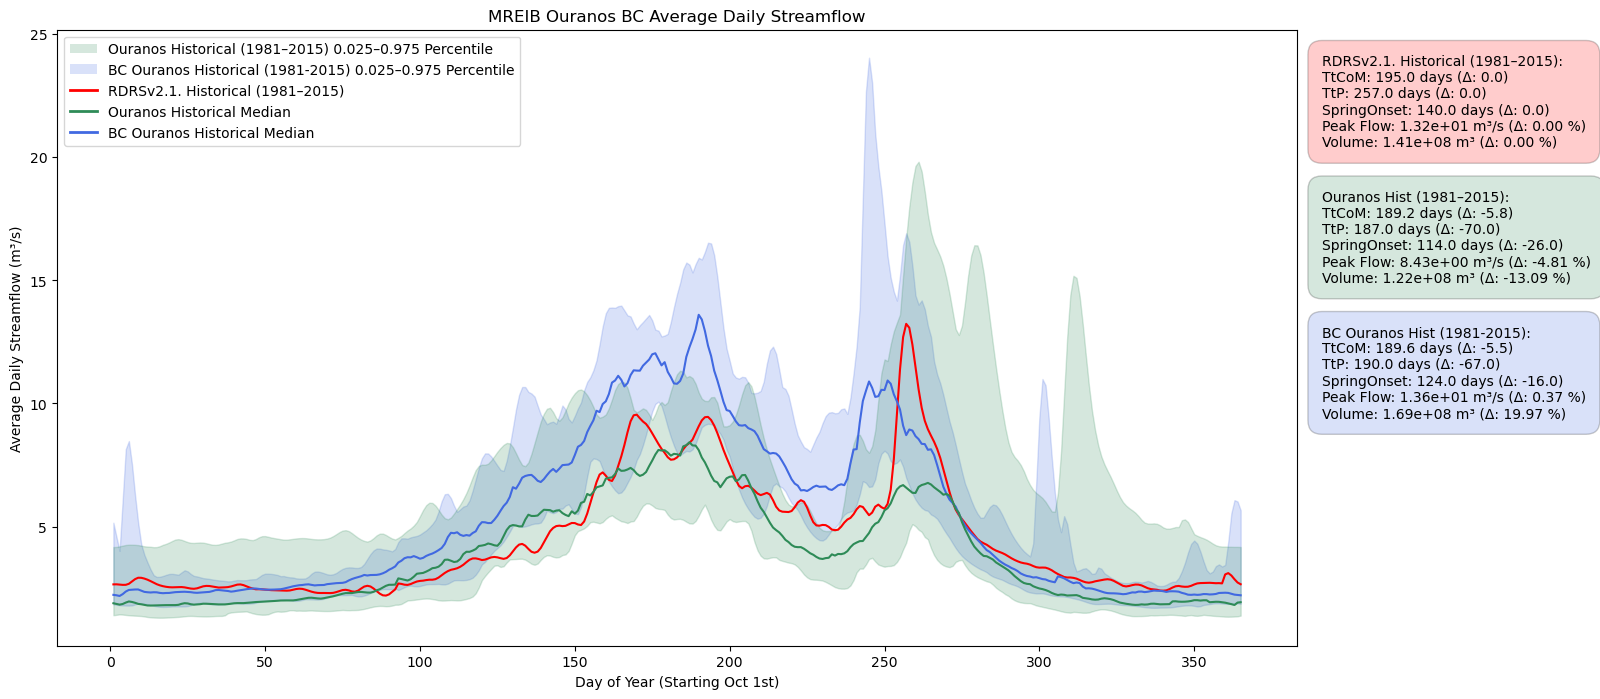

In [25]:
plot_bias_corrected_vs_historical(
    location= 'MREIB',
    variable=variable,
    variable_name=variable_name,
    variable_unit='m³/s',
    bc_type= 'BC',
    mreib_historical=mreib_historical,
    mreib_hist_ssp245=mreib_hist_ssp245,
    mreib_hist_ssp370=mreib_hist_ssp370,
    bc_mreib_hist_ssp245=bc_mreib_hist_ssp245,
    bc_mreib_hist_ssp370=bc_mreib_hist_ssp370,
    output_directory=output_directory,
    combine_ensembles=combine_ensembles,
    compute_hydrologic_metrics=compute_hydrologic_metrics,
    mreib_obs_historical=None  # optional
)

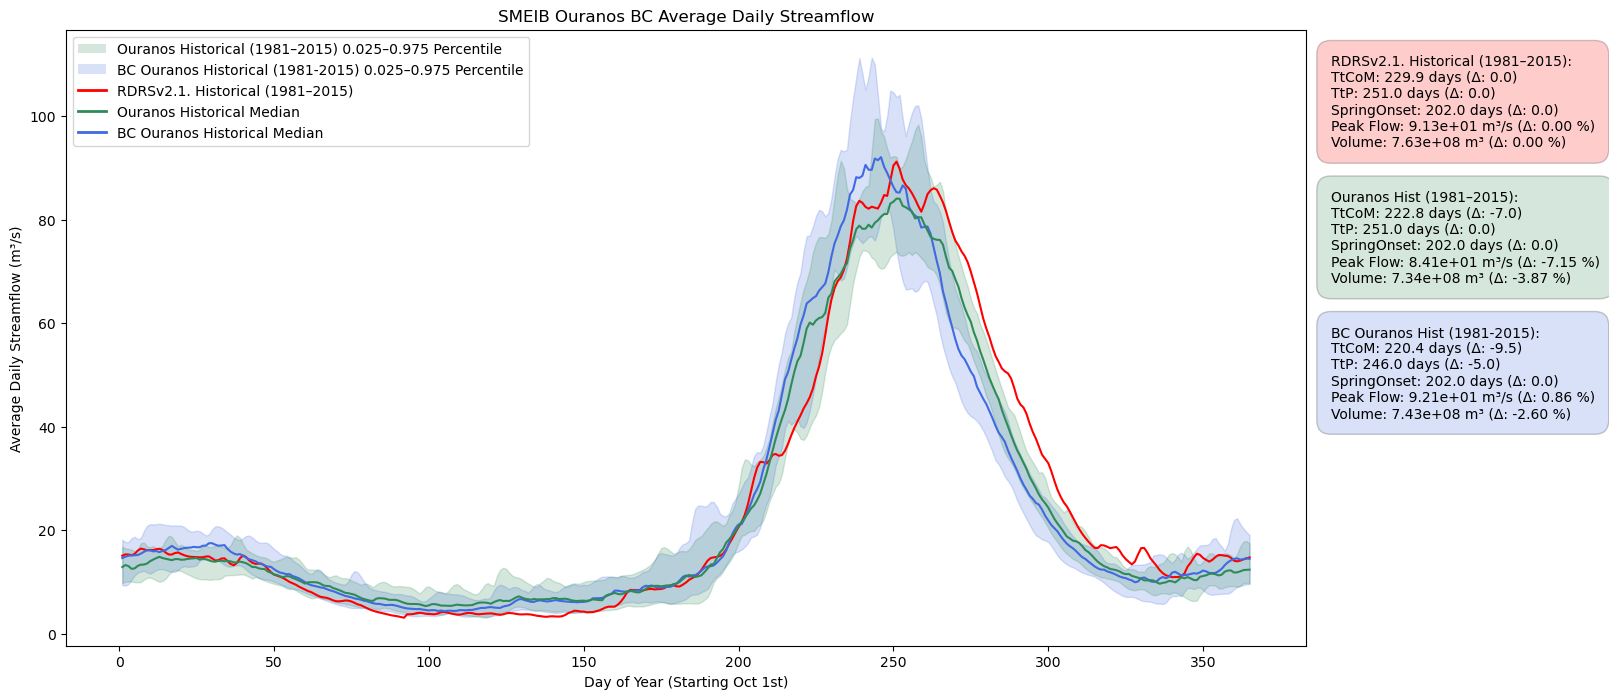

In [26]:
plot_bias_corrected_vs_historical(
    location= 'SMEIB',
    variable=variable,
    variable_name=variable_name,
    variable_unit='m³/s',
    bc_type= 'BC',
    mreib_historical=smrib_historical,
    mreib_hist_ssp245=smrib_hist_ssp245,
    mreib_hist_ssp370=smrib_hist_ssp370,
    bc_mreib_hist_ssp245=bc_smrib_hist_ssp245,
    bc_mreib_hist_ssp370=bc_smrib_hist_ssp370,
    output_directory=output_directory,
    combine_ensembles=combine_ensembles,
    compute_hydrologic_metrics=compute_hydrologic_metrics,
    mreib_obs_historical=None  # optional
)

### No Drizzle Pseudo Hist Comparison

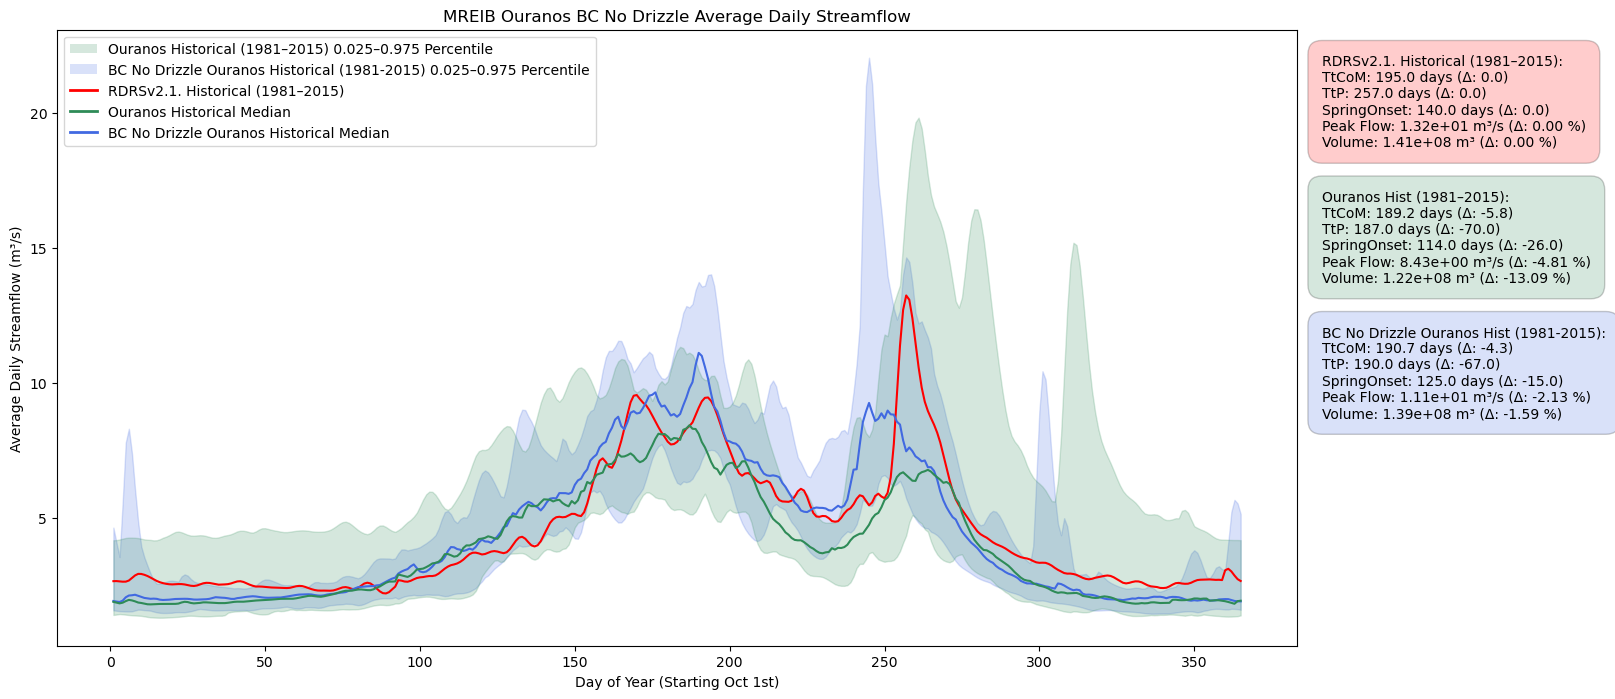

In [27]:
plot_bias_corrected_vs_historical(
    location= 'MREIB',
    variable=variable,
    variable_name=variable_name,
    variable_unit='m³/s',
    bc_type= 'BC No Drizzle',
    mreib_historical=mreib_historical,
    mreib_hist_ssp245=mreib_hist_ssp245,
    mreib_hist_ssp370=mreib_hist_ssp370,
    bc_mreib_hist_ssp245=no_drizz_bc_mreib_hist_ssp245,
    bc_mreib_hist_ssp370=no_drizz_bc_mreib_hist_ssp370,
    output_directory=output_directory,
    combine_ensembles=combine_ensembles,
    compute_hydrologic_metrics=compute_hydrologic_metrics,
    mreib_obs_historical=None  # optional
)

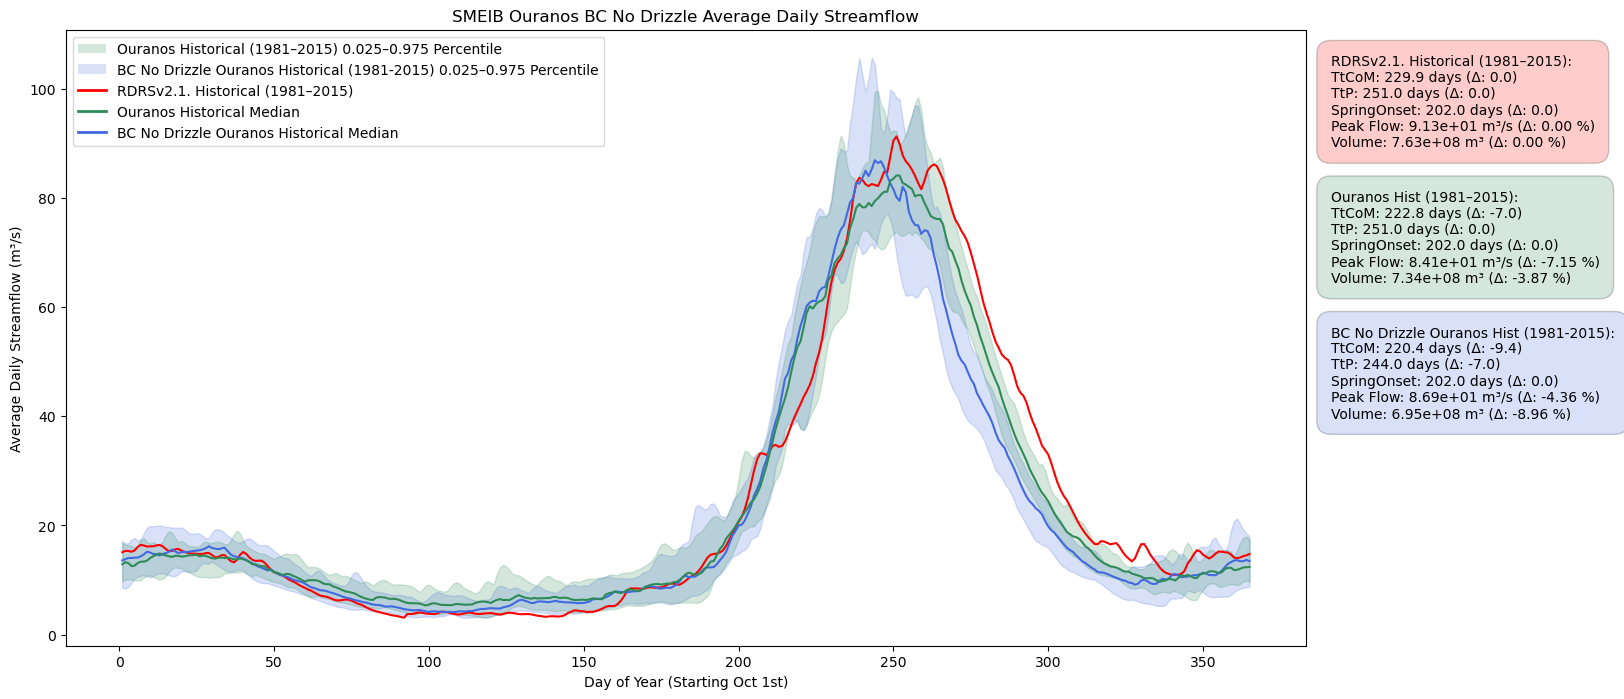

In [28]:
plot_bias_corrected_vs_historical(
    location= 'SMEIB',
    variable=variable,
    variable_name=variable_name,
    variable_unit='m³/s',
    bc_type= 'BC No Drizzle',
    mreib_historical=smrib_historical,
    mreib_hist_ssp245=smrib_hist_ssp245,
    mreib_hist_ssp370=smrib_hist_ssp370,
    bc_mreib_hist_ssp245=no_drizz_bc_smrib_hist_ssp245,
    bc_mreib_hist_ssp370=no_drizz_bc_smrib_hist_ssp370,
    output_directory=output_directory,
    combine_ensembles=combine_ensembles,
    compute_hydrologic_metrics=compute_hydrologic_metrics,
    mreib_obs_historical=None  # optional
)